# IoT Intrusion Detection Project
## Milestone 1 — Data Inspection

This notebook corresponds to **Step 1 of the brief**: *"Ingest and validate the dataset. Inspect
the schema, check missing values, and measure class balance."*

Scope:
- Load all per-attack CSVs from `../data/raw/` and concatenate them into a single labelled DataFrame.
- Inspect schema, dtypes, and column list.
- Measure class balance (with a plot, since the imbalance is the whole point of Section 5 of the brief).
- Quantify missing / infinite values and duplicates.
- Remove exact duplicates and save a cleaned (but **not yet imputed**) dataset for Milestone 2.

**Imputation and scaling are deliberately deferred to Milestone 2**, where they are fit on the
training split only to avoid leakage (brief Section 6, Step 3).

## 1. Setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

## 2. Load & combine raw files

Each CSV in `../data/raw/` contains traffic from one class. The filename is the class label, so
we add a `label` column derived from the filename before concatenating.

In [2]:
data_path = "../data/raw"
files = sorted(f for f in os.listdir(data_path) if f.endswith(".csv"))

print("Files found:")
for f in files:
    print(" -", f)

Files found:
 - BenignTraffic.csv
 - DDoS-ICMP_Flood.csv
 - DictionaryBruteForce.csv
 - DoS-SYN_Flood.csv
 - MITM-ArpSpoofing.csv
 - Mirai-greeth_flood.csv
 - Recon-PortScan.csv
 - SqlInjection.csv


In [3]:
dfs = []
for file in files:
    df_part = pd.read_csv(os.path.join(data_path, file))
    df_part["label"] = file.replace(".csv", "")
    dfs.append(df_part)

combined_df = pd.concat(dfs, ignore_index=True)
print("Combined shape:", combined_df.shape)

Combined shape: (1274958, 40)


## 3. Schema & dtypes

In [4]:
combined_df.head()

,Header_Length,Protocol Type,Time_To_Live,Rate,fin_flag_number,syn_flag_number,rst_flag_number,psh_flag_number,ack_flag_number,ece_flag_number,...,Tot sum,Min,Max,AVG,Std,Tot size,IAT,Number,Variance,label
0,32.0,6,198.4,430.273287,0.0,0.0,0.0,0.0,1.0,0.0,...,5004,66,2962,500.4,977.325512,500.4,0.002324,10,9.551652e+05,BenignTraffic
1,22.4,6,114.4,484.616113,0.0,0.0,0.0,0.2,0.6,0.0,...,1404,60,583,140.4,174.827026,140.4,0.002179,10,3.056449e+04,BenignTraffic
2,27.2,6,62.5,398.610950,0.0,0.0,0.0,0.0,0.8,0.0,...,10784,60,1514,1078.4,701.384536,1078.4,0.003173,10,4.919403e+05,BenignTraffic
3,23.2,6,62.1,425.187438,0.0,0.1,0.0,0.0,0.6,0.0,...,7884,60,2962,788.4,1025.156812,788.4,0.002507,10,1.050946e+06,BenignTraffic
4,32.0,6,64.0,1563.521956,0.0,0.0,0.0,0.1,1.0,0.0,...,13782,156,1514,1378.2,429.437306,1378.2,0.000660,10,1.844164e+05,BenignTraffic


In [5]:
combined_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1274958 entries, 0 to 1274957
Data columns (total 40 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   Header_Length    1274958 non-null  float64
 1   Protocol Type    1274958 non-null  int64  
 2   Time_To_Live     1274958 non-null  float64
 3   Rate             1274958 non-null  float64
 4   fin_flag_number  1274958 non-null  float64
 5   syn_flag_number  1274958 non-null  float64
 6   rst_flag_number  1274958 non-null  float64
 7   psh_flag_number  1274958 non-null  float64
 8   ack_flag_number  1274958 non-null  float64
 9   ece_flag_number  1274958 non-null  float64
 10  cwr_flag_number  1274958 non-null  float64
 11  ack_count        1274958 non-null  int64  
 12  syn_count        1274958 non-null  int64  
 13  fin_count        1274958 non-null  int64  
 14  rst_count        1274958 non-null  int64  
 15  HTTP             1274958 non-null  float64
 16  HTTPS            1274958 non-

In [6]:
combined_df.dtypes

Header_Length      float64
Protocol Type        int64
Time_To_Live       float64
Rate               float64
fin_flag_number    float64
syn_flag_number    float64
rst_flag_number    float64
psh_flag_number    float64
ack_flag_number    float64
ece_flag_number    float64
cwr_flag_number    float64
ack_count            int64
syn_count            int64
fin_count            int64
rst_count            int64
HTTP               float64
HTTPS              float64
DNS                float64
Telnet             float64
SMTP               float64
SSH                float64
IRC                float64
TCP                float64
UDP                float64
DHCP               float64
ARP                float64
ICMP               float64
IGMP               float64
IPv                float64
LLC                float64
Tot sum              int64
Min                  int64
Max                  int64
AVG                float64
Std                float64
Tot size           float64
IAT                float64
N

## 4. Class balance

Per the brief (Section 5), a high accuracy number can be misleading when some attack classes are
much rarer than others. Visualising the imbalance now makes the later emphasis on macro-F1 and
per-class recall obvious.

In [7]:
class_counts = combined_df["label"].value_counts()
print(class_counts)
print()
print("Imbalance ratio (majority / minority):",
      round(class_counts.max() / class_counts.min(), 1))

label
BenignTraffic           362361
DDoS-ICMP_Flood         268010
DoS-SYN_Flood           262691
MITM-ArpSpoofing        247706
Recon-PortScan           82284
Mirai-greeth_flood       33597
DictionaryBruteForce     13064
SqlInjection              5245
Name: count, dtype: int64

Imbalance ratio (majority / minority): 69.1


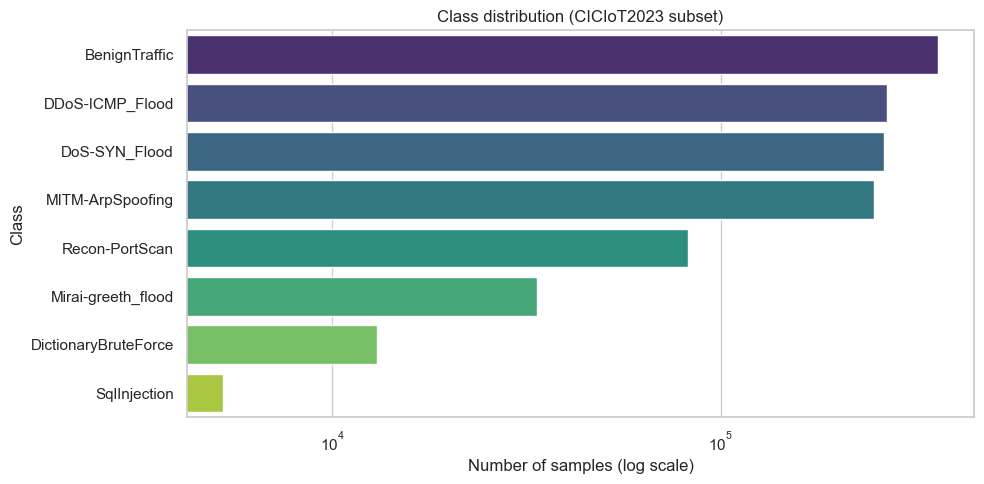

In [8]:
plt.figure(figsize=(10, 5))
sns.barplot(
    x=class_counts.values,
    y=class_counts.index,
    hue=class_counts.index,
    palette="viridis",
    legend=False,
)
plt.xscale("log")
plt.xlabel("Number of samples (log scale)")
plt.ylabel("Class")
plt.title("Class distribution (CICIoT2023 subset)")
plt.tight_layout()
plt.show()

## 5. Missing and infinite values

Only count, don't fix here. Imputation is done in Milestone 2 on the training split only.

In [9]:
nan_counts = combined_df.isnull().sum()
nan_counts = nan_counts[nan_counts > 0]
print("Columns with NaN values:")
print(nan_counts if len(nan_counts) else "  (none)")

Columns with NaN values:
Std         45
Variance    45
dtype: int64


In [10]:
numeric = combined_df.select_dtypes(include=[np.number])
inf_counts = np.isinf(numeric).sum()
inf_counts = inf_counts[inf_counts > 0]
print("Columns with infinite values:")
print(inf_counts if len(inf_counts) else "  (none)")

Columns with infinite values:
Rate    50
dtype: int64


## 6. Duplicate rows

Duplicates are expected to be substantial in this dataset — flood attacks generate many packets
with near-identical feature vectors, and the feature extractor aggregates in a way that collapses
them to exact duplicates. We remove exact duplicates once; near-duplicates that survive are handled
more safely in Milestone 2 by using an ordered per-class split instead of random row-level splitting
(brief Section 6, Step 2).

In [11]:
n_duplicates = combined_df.duplicated().sum()
print(f"Exact duplicate rows: {n_duplicates:,} "
      f"({n_duplicates / len(combined_df):.1%} of dataset)")

Exact duplicate rows: 189,911 (14.9% of dataset)


In [12]:
rows_before = len(combined_df)
combined_df = combined_df.drop_duplicates().reset_index(drop=True)
rows_after = len(combined_df)

print(f"Rows before: {rows_before:,}")
print(f"Rows after:  {rows_after:,}")
print(f"Removed:     {rows_before - rows_after:,}")

Rows before: 1,274,958
Rows after:  1,085,047
Removed:     189,911


## 7. Quick look at a key feature

A boxplot of `Rate` (packets-per-second) per class gives a quick visual sanity check that the
classes are actually separable on at least some features — floods sit at high rates, benign
traffic sits low.

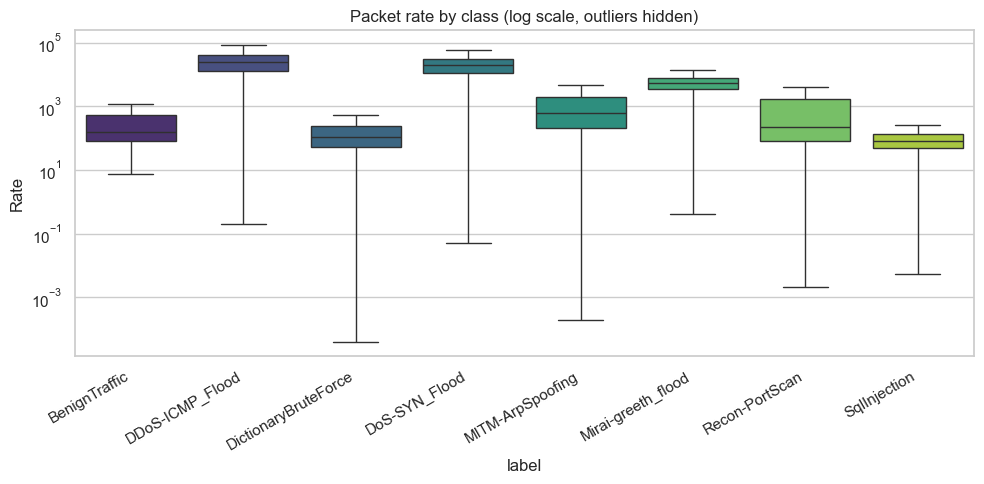

In [13]:
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=combined_df,
    x="label",
    y="Rate",
    hue="label",
    palette="viridis",
    legend=False,
    showfliers=False,
)
plt.yscale("log")
plt.xticks(rotation=30, ha="right")
plt.title("Packet rate by class (log scale, outliers hidden)")
plt.tight_layout()
plt.show()

## 8. Save cleaned dataset

Saved *as is* — NaN and inf values are preserved and will be handled in Milestone 2 on the
training split only. This avoids the leakage pattern the brief warns about in Step 3.

In [14]:
os.makedirs("../data/processed", exist_ok=True)

clean_path = "../data/processed/clean_dataset.csv"
combined_df.to_csv(clean_path, index=False)

print(f"Saved cleaned dataset -> {clean_path}")
print(f"Shape: {combined_df.shape}")

Saved cleaned dataset -> ../data/processed/clean_dataset.csv
Shape: (1085047, 40)


## Summary

- Loaded 8 per-class CSVs into a single DataFrame with a `label` column.
- Class distribution is highly imbalanced (see plot above); this motivates the use of **macro-F1**
  and **per-class recall** in Milestone 3 rather than raw accuracy.
- Missing values were found in a small number of numeric columns; infinite values were also
  present. Both are left in the saved dataset and handled in Milestone 2 **after** the train/val/test
  split so that imputation statistics are computed from training data only.
- Exact duplicates were removed; remaining near-duplicates are addressed in Milestone 2 with an
  ordered per-class split that reduces leakage compared with random row-level splitting.